In [72]:
!git clone https://github.com/samuelmatia/shift-gnn-challenge.git

fatal: destination path 'shift-gnn-challenge' already exists and is not an empty directory.


In [73]:
!pip install torch-geometric

In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch.optim import Adam
import torch.nn as nn
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import time

In [75]:
SEED = 25
np.random.seed(25)

In [76]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [77]:
train_df = pd.read_parquet('/content/shift-gnn-challenge/data/processed/train.parquet')
train_df.head()

,user_id,snapshot_id,current_role,next_role,transition_label,snapshot_start,snapshot_end,next_snapshot_start,next_snapshot_end
0,19834,14,2,0,2->0,2008-08-02 04:32:45,2008-11-02 04:32:45,2008-11-02 04:32:45,2009-02-02 04:32:45
1,19834,19,0,2,0->2,2008-11-02 04:32:45,2009-02-02 04:32:45,2009-02-02 04:32:45,2009-05-02 04:32:45
2,19834,8,2,3,2->3,2009-02-02 04:32:45,2009-05-02 04:32:45,2009-05-02 04:32:45,2009-08-02 04:32:45
3,19834,10,3,4,3->4,2009-05-02 04:32:45,2009-08-02 04:32:45,2009-08-02 04:32:45,2009-11-02 04:32:45
4,19834,29,4,4,4->4,2009-08-02 04:32:45,2009-11-02 04:32:45,2009-11-02 04:32:45,2010-02-02 04:32:45


In [78]:
nodes_df = pd.read_parquet('/content/shift-gnn-challenge/data/processed/node_features_all.parquet')
nodes_df.head()

,user_id,snapshot_id,out_degree,in_degree,num_unique_recipients,num_unique_sources,total_interactions,activity_span_days,avg_interactions_per_day
0,4412,0,1,0,1,0,1,1,1.000000
1,1255,0,1,12,1,12,13,61,0.213115
2,1633,0,1,0,1,0,1,1,1.000000
3,98541,0,1,0,1,0,1,1,1.000000
4,4229,0,1,0,1,0,1,1,1.000000


In [79]:
adj_df = pd.read_parquet('/content/shift-gnn-challenge/data/processed/adjacency_all.parquet')
adj_df.head()

,src,dst,snapshot_id
0,4412,1255,0
1,1633,1255,0
2,98541,1255,0
3,4229,361,0
4,2409,361,0


In [80]:
test_df = pd.read_parquet('/content/shift-gnn-challenge/data/processed/test_features.parquet')
test_df

,user_id,snapshot_id,current_role,snapshot_start,snapshot_end
0,21241,16,0,2015-05-02 04:32:45,2015-08-02 04:32:45
1,3517,4,0,2015-11-02 04:32:45,2016-02-02 04:32:45
2,12242,18,0,2015-02-02 04:32:45,2015-05-02 04:32:45
3,18642,18,0,2015-02-02 04:32:45,2015-05-02 04:32:45
4,1019,18,0,2015-02-02 04:32:45,2015-05-02 04:32:45
...,...,...,...,...,...
186153,48092,16,1,2015-05-02 04:32:45,2015-08-02 04:32:45
186154,43958,18,0,2015-02-02 04:32:45,2015-05-02 04:32:45
186155,476,4,0,2015-11-02 04:32:45,2016-02-02 04:32:45
186156,18392,18,0,2015-02-02 04:32:45,2015-05-02 04:32:45


In [81]:
print(f"Train shape = {train_df.shape}")
print(f"Test Shape = {test_df.shape}")
print(f'Adjancecy Matrix shape = {adj_df.shape}')
print(f"Nodes matrix shape = {nodes_df.shape}")

Train shape = (490957, 9)
Test Shape = (186158, 5)
Adjancecy Matrix shape = (403843, 3)
Nodes matrix shape = (726903, 9)


In [82]:
snapshots = train_df['snapshot_id'].unique()
print(f"Total snapshots = {len(snapshots)}")

Total snapshots = 26


In [83]:
snapshots_counts = train_df.groupby('snapshot_id').size()

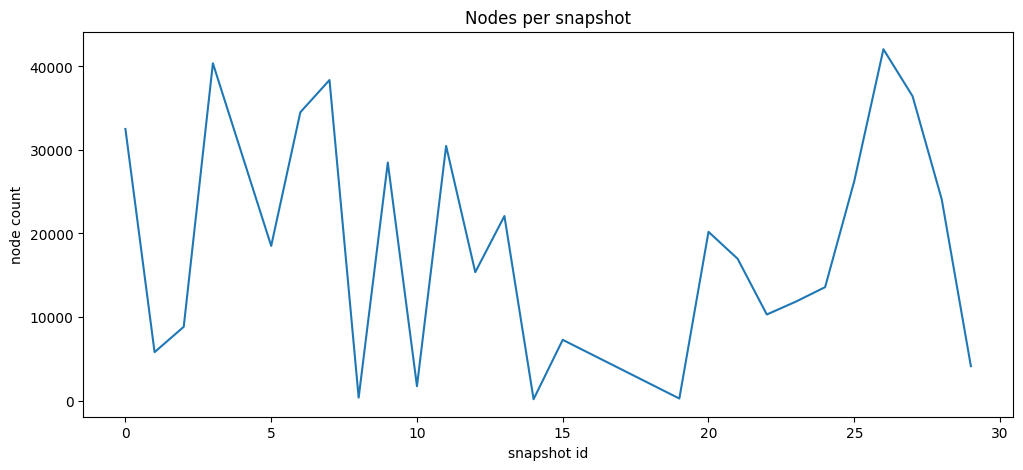

In [84]:
plt.figure(figsize=(12,5))
snapshots_counts.plot()
plt.title("Nodes per snapshot")
plt.xlabel("snapshot id")
plt.ylabel('node count')
plt.show()

In [85]:
role_counts = train_df['current_role'].value_counts().sort_index()
role_counts

,count
current_role,
0,360278
1,41197
2,61919
3,22520
4,5043


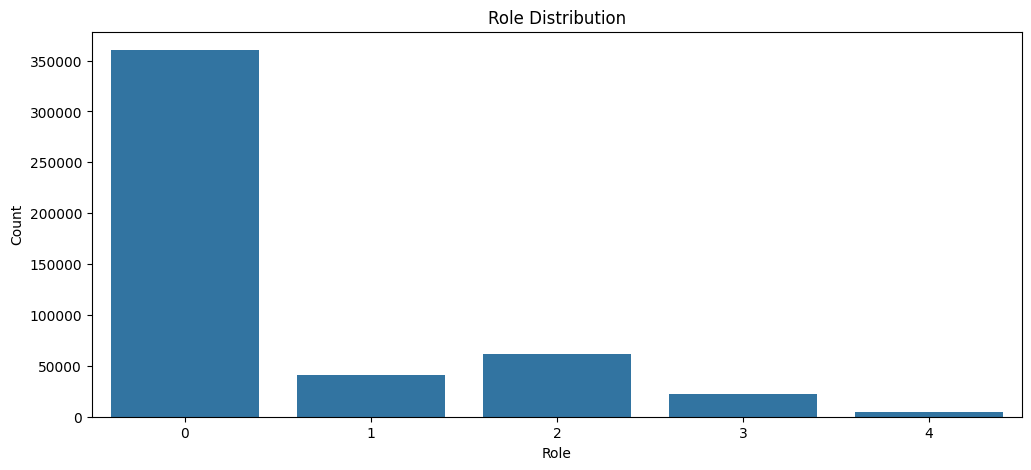

In [86]:
plt.figure(figsize=(12,5))
sns.barplot(x=role_counts.index,y=role_counts.values)
plt.title("Role Distribution")
plt.xlabel("Role")
plt.ylabel("Count")
plt.show()

In [87]:
role_counts.index

Index([0, 1, 2, 3, 4], dtype='int64', name='current_role')

In [88]:
transition_matrix = pd.crosstab(
    train_df['current_role'],
    train_df['next_role']
)

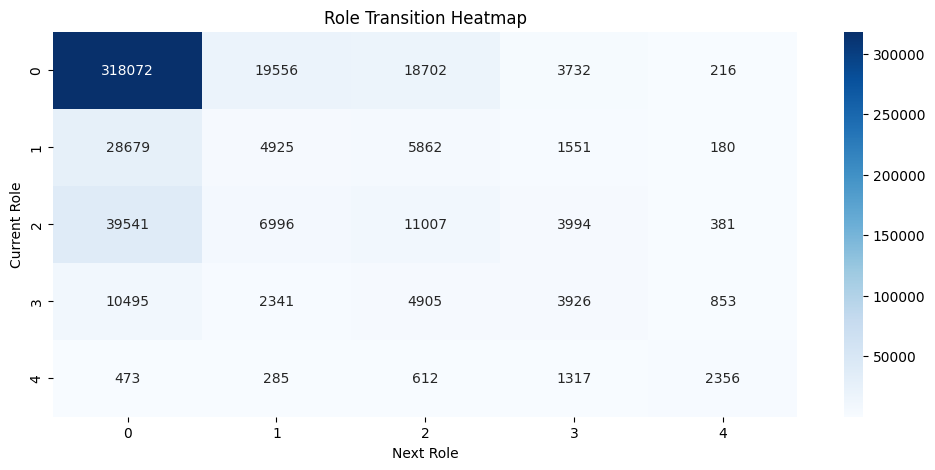

In [89]:
plt.figure(figsize=(12,5))
sns.heatmap(
    transition_matrix,
    annot=True,
    fmt='d',
    cmap="Blues"
)
plt.title("Role Transition Heatmap")
plt.xlabel("Next Role")
plt.ylabel("Current Role")
plt.show()

In [90]:
transition_matrix

next_role,0,1,2,3,4
current_role,,,,,
0,318072,19556,18702,3732,216
1,28679,4925,5862,1551,180
2,39541,6996,11007,3994,381
3,10495,2341,4905,3926,853
4,473,285,612,1317,2356


In [91]:
transition_freq = transition_matrix / transition_matrix.values.sum()
rare_transitions = transition_freq[transition_freq < 0.01]
print(rare_transitions.dropna(how='all'))

next_role            0         1         2         3         4
current_role                                                  
0                  NaN       NaN       NaN  0.007601  0.000440
1                  NaN       NaN       NaN  0.003159  0.000367
2                  NaN       NaN       NaN  0.008135  0.000776
3                  NaN  0.004768  0.009991  0.007997  0.001737
4             0.000963  0.000580  0.001247  0.002683  0.004799


In [92]:
sample_edges = adj_df.sample(min(len(adj_df),20000),random_state=SEED)
sample_edges.head()

,src,dst,snapshot_id
357776,415613,175982,27
40052,25949,1304,5
199659,92371,157882,16
296530,1495,8804,22
384962,387177,518457,29


In [93]:
G = nx.Graph()
G.add_edges_from(
    zip(sample_edges['src'],sample_edges['dst'])
)
print(f"graph nodes=  {G.number_of_nodes()}")
print(f'graph edges = {G.number_of_edges()}')

graph nodes=  15842
graph edges = 19657


In [94]:
degrees = [d for n,d in G.degree()]

Text(0, 0.5, 'Frequencey')

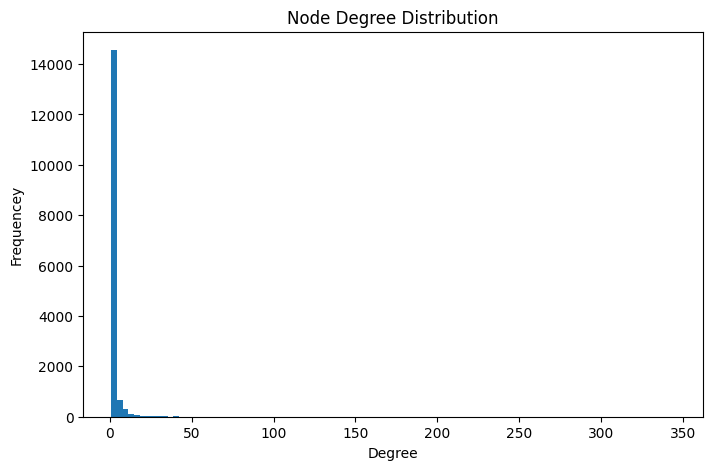

In [95]:
plt.figure(figsize=(8,5))
plt.hist(degrees,bins=100)
plt.title("Node Degree Distribution")
plt.xlabel('Degree')
plt.ylabel('Frequencey')

In [96]:
train_df.head(2)

,user_id,snapshot_id,current_role,next_role,transition_label,snapshot_start,snapshot_end,next_snapshot_start,next_snapshot_end
0,19834,14,2,0,2->0,2008-08-02 04:32:45,2008-11-02 04:32:45,2008-11-02 04:32:45,2009-02-02 04:32:45
1,19834,19,0,2,0->2,2008-11-02 04:32:45,2009-02-02 04:32:45,2009-02-02 04:32:45,2009-05-02 04:32:45


In [97]:
all_users = pd.concat([train_df['user_id'],adj_df['src'],adj_df['dst']]).unique()
all_users = np.sort(all_users)
user2id = {u:i for i, u in enumerate(all_users)}

In [98]:
num_nodes = len(user2id)
print(f"Total nodes=  {num_nodes}")

Total nodes=  82543


In [99]:
train_df['nid'] = train_df['user_id'].map(user2id)
adj_df['src_nid'] = adj_df['src'].map(user2id)
adj_df['dst_nid'] = adj_df['dst'].map(user2id)
nodes_df['nid'] = nodes_df['user_id'].map(user2id)

In [100]:
nodes_df = nodes_df.sort_values(['user_id','snapshot_id'])
feat_cols = ['out_degree','in_degree','total_interactions','activity_span_days']

In [101]:
for col in feat_cols:
  nodes_df[f'{col}_delta'] = nodes_df.groupby('user_id')[col].diff().fillna(0)

In [102]:
nodes_df.head(2)

,user_id,snapshot_id,out_degree,in_degree,num_unique_recipients,num_unique_sources,total_interactions,activity_span_days,avg_interactions_per_day,nid,out_degree_delta,in_degree_delta,total_interactions_delta,activity_span_days_delta
32,1,0,2,2,2,2,4,51,0.078431,1,0.0,0.0,0.0,0.0
257,1,1,0,0,0,0,0,0,0.000000,1,-2.0,-2.0,-4.0,-51.0


In [103]:
final_feats = feat_cols + [f'{c}_delta' for c in feat_cols]

In [104]:
scaler = StandardScaler()
nodes_df[final_feats] = scaler.fit_transform(nodes_df[final_feats])

In [105]:
nodes_df.head(2)

,user_id,snapshot_id,out_degree,in_degree,num_unique_recipients,num_unique_sources,total_interactions,activity_span_days,avg_interactions_per_day,nid,out_degree_delta,in_degree_delta,total_interactions_delta,activity_span_days_delta
32,1,0,0.168783,0.278461,2,2,0.220921,5.086646,0.078431,1,0.038407,0.064607,0.051922,0.026425
257,1,1,-0.102765,-0.169543,0,0,-0.134510,-0.164882,0.000000,1,-0.364155,-0.481291,-0.433884,-4.387612


In [106]:
snapshots = sorted(nodes_df['snapshot_id'].unique())
graph_data = {}

In [107]:
id2user = torch.tensor(all_users, dtype=torch.long)

In [108]:
for snap_id in snapshots:
  edge_index = torch.tensor(adj_df[adj_df['snapshot_id'] == snap_id][['src_nid','dst_nid']].values,dtype=torch.long).t().contiguous()
  edge_index = torch.cat([edge_index,edge_index.flip(0)],dim=1)
  n_mask = nodes_df['snapshot_id'] == snap_id
  x = torch.zeros((num_nodes,len(final_feats)),dtype=torch.float)
  n_ids = nodes_df.loc[n_mask,'nid'].values
  n_feats = nodes_df.loc[n_mask,final_feats].values
  x[n_ids] = torch.tensor(n_feats, dtype=torch.float)
  graph_data[snap_id] = Data(x=x, edge_index=edge_index, user_id=id2user)


In [109]:
len(graph_data)

31

In [110]:
graph_data[0]

Data(x=[82543, 8], edge_index=[2, 350], user_id=[82543])

In [111]:
for snap_id, data in graph_data.items():
  snap_labels = train_df[train_df["snapshot_id"] == snap_id]
  y = torch.full((num_nodes,),-1,dtype=torch.long)
  if not snap_labels.empty:
    y[snap_labels['nid'].values] = torch.tensor(snap_labels['next_role'].values, dtype=torch.long)

  data.y = y

In [112]:
train_snapshots = [i for i in range(20)]
val_snapshots = [i for i in range(20,26)]

In [113]:
train_graphs = [graph_data[i] for i in train_snapshots if i in graph_data]
val_graphs = [graph_data[i] for i in val_snapshots if i in graph_data]

In [114]:
print(f"training snapshot length = {len(train_graphs)}")
print(f"validation snapshot length = {len(val_graphs)}")

training snapshot length = 20
validation snapshot length = 6


In [115]:
role_counts = train_df['next_role'].value_counts().sort_index()
class_weights = 1.0 / role_counts.values
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * len(role_counts)

In [116]:
class_weights

tensor([0.0335, 0.3900, 0.3237, 0.9160, 3.3368])

In [117]:
role_ids = list(range(5))
df = pd.DataFrame({
    'role': role_ids,
    'weights': class_weights.numpy()
})

print(df)

   role   weights
0     0  0.033480
1     1  0.390009
2     2  0.323707
3     3  0.916010
4     4  3.336795


# GCN

In [118]:
class GCN(nn.Module):
  def __init__(self,in_channels,hidden_channels,output_channels):
    super().__init__()
    self.conv1 = GCNConv(in_channels,hidden_channels)
    self.conv2 = GCNConv(hidden_channels, output_channels)

  def forward(self,x,edge_index):
    x = self.conv1(x,edge_index).relu()
    x = F.dropout(x,p=0.5,training=self.training)
    x =  self.conv2(x,edge_index)
    return x



In [119]:
model_gcn = GCN(8,64,5)
model_gcn = model_gcn.to(device)
optimizer_gcn = Adam(model_gcn.parameters(),lr=0.01)
criterion_gcn = nn.CrossEntropyLoss(weight=class_weights.to(device))

In [120]:
model_gcn

GCN(
  (conv1): GCNConv(8, 64)
  (conv2): GCNConv(64, 5)
)

In [121]:
def train(model,criterion,optimizer):
  model.train()
  total_loss = 0
  for data in train_graphs:
    data = data.to(device)
    optimizer.zero_grad()
    out = model(data.x,data.edge_index)
    mask = data.y != -1
    loss = criterion(out[mask], data.y[mask])
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    return total_loss / len(train_graphs)

In [122]:
@torch.no_grad()
def validate(model,criterion,optimizer):
  model.eval()
  correct = 0
  total = 0
  all_preds = []
  all_labels = []
  for data in val_graphs:
    data = data.to(device)
    out = model(data.x,data.edge_index)
    pred = out.argmax(dim=1)
    mask = data.y != -1
    all_preds.append(pred[mask].cpu().numpy())
    all_labels.append(data.y[mask].cpu().numpy())
    correct += (pred[mask]  == data.y[mask]).sum().item()
    total += mask.sum().item()
  all_preds = np.concatenate(all_preds)
  all_labels = np.concatenate(all_labels)
  return correct/total, all_preds, all_labels

In [123]:
best_val_macro_f1 = 0.0
print("-----------GCN--------- ")
for epoch in range(1,51):
  loss = train(model_gcn,criterion_gcn,optimizer_gcn)
  acc,p,l = validate(model_gcn,criterion_gcn,optimizer_gcn)
  report = classification_report(l,p,output_dict=True,zero_division=0)
  current_macro_f1 = report['macro avg']['f1-score']
  if epoch%10 == 0:

    print(f'Epoch: {epoch:03d} | Loss: {loss:.4f} | Val Acc: {acc:.4f} | Macro F1: {current_macro_f1:.4f}')

  if current_macro_f1 > best_val_macro_f1:
    best_val_macro_f1 = current_macro_f1
    torch.save(model_gcn.state_dict(), "best_gcn_model.pth")

-----------GCN--------- 
Epoch: 010 | Loss: 0.0797 | Val Acc: 0.7580 | Macro F1: 0.1738
Epoch: 020 | Loss: 0.0795 | Val Acc: 0.7497 | Macro F1: 0.1771
Epoch: 030 | Loss: 0.0795 | Val Acc: 0.7477 | Macro F1: 0.1775
Epoch: 040 | Loss: 0.0795 | Val Acc: 0.7449 | Macro F1: 0.1781
Epoch: 050 | Loss: 0.0795 | Val Acc: 0.7439 | Macro F1: 0.1784


In [124]:
model_gcn.load_state_dict(torch.load("best_gcn_model.pth"))

<All keys matched successfully>

In [125]:
model_gcn.eval()
all_preds = []
all_labels = []
start_time = time.time()
with torch.no_grad():
  for data in val_graphs:
    data = data.to(device)
    out = model_gcn(data.x,data.edge_index)
    pred = out.argmax(dim=1)
    mask = data.y != -1
    all_preds.append(pred[mask].cpu().numpy())
    all_labels.append(data.y[mask].cpu().numpy())
end_time = time.time()
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

In [126]:
target_names = ['Inactive', 'Novice', 'Contributor', 'Expert', 'Moderator']
print(classification_report(all_labels, all_preds, target_names=target_names))

              precision    recall  f1-score   support

    Inactive       0.76      0.97      0.85     75469
      Novice       0.08      0.01      0.02      7950
 Contributor       0.09      0.00      0.01     10890
      Expert       0.04      0.02      0.02      3753
   Moderator       0.00      0.00      0.00      1105

    accuracy                           0.74     99167
   macro avg       0.19      0.20      0.18     99167
weighted avg       0.60      0.74      0.65     99167



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


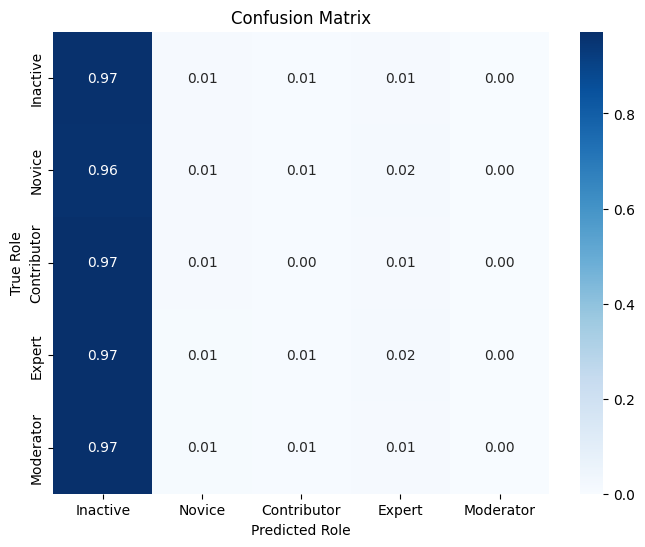

In [127]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8,6))
sns.heatmap(cm_norm,annot=True,fmt='.2f',cmap="Blues",xticklabels=target_names,yticklabels=target_names)
plt.title("Confusion Matrix")
plt.ylabel("True Role")
plt.xlabel("Predicted Role")
plt.show()

# Submission

In [148]:
test_features_df = pd.read_parquet('/content/shift-gnn-challenge/data/processed/test_features.parquet')
test_snapshots = sorted(test_features_df['snapshot_id'].unique())

In [149]:
submission_df = test_features_df[['user_id', 'snapshot_id']].copy()

In [150]:
submission_df

,user_id,snapshot_id
0,21241,16
1,3517,4
2,12242,18
3,18642,18
4,1019,18
...,...,...
186153,48092,16
186154,43958,18
186155,476,4
186156,18392,18


In [151]:
all_results = []

In [152]:
model_gcn.eval()
DEFAULT_ROLE = 0

with torch.no_grad():
    for snap_id in test_snapshots:
        if snap_id not in graph_data:
            mask = test_features_df['snapshot_id'] == snap_id
            all_results.append(pd.Series(DEFAULT_ROLE, index=test_features_df.index[mask]))
            continue

        data = graph_data[snap_id].to(device)
        out = model_gcn(data.x, data.edge_index)
        preds = out.argmax(dim=1).cpu().numpy()

        mask = test_features_df['snapshot_id'] == snap_id
        snap_indices = test_features_df.index[mask]
        snap_user_ids = test_features_df.loc[mask, 'user_id']
        mapped_nids = snap_user_ids.map(user2id)

        is_valid = mapped_nids.notna()

        final_snap_preds = np.full(len(snap_user_ids), DEFAULT_ROLE)

        if is_valid.any():
            valid_nids = mapped_nids[is_valid].astype(int).values
            final_snap_preds[is_valid.values] = preds[valid_nids]
        snap_preds_series = pd.Series(final_snap_preds, index=snap_indices)
        all_results.append(snap_preds_series)


In [153]:
submission_df['predicted_role'] = pd.concat(all_results).sort_index()
submission_df.to_csv('submission.csv', index=False)
submission_df.head()

,user_id,snapshot_id,predicted_role
0,21241,16,0
1,3517,4,0
2,12242,18,0
3,18642,18,0
4,1019,18,0


In [154]:
submission_df.shape

(186158, 3)